# From CHD history to an auditable MDRAP research run

**BTCUSDT · Binance spot · one full hour of historical trades**

Download an hourly CryptoHFTData file, select an exact UTC interval, and process
it through MDRAP's quality and storage pipeline. Inspect source provenance,
replay the archive, and chart prices, VWAP and volume using MDRAP's OHLCV output.

The walkthrough uses the repository's `CHDClient`, `HistoricalRequest`,
`ingest_history`, `Pipeline`, `RawArchive` replay reader and `MarketAnalytics`.
Every chart comes from the data you actually download.

| Stage | Result |
| :--- | :--- |
| Discover & plan | Exact exchange symbol and hourly file keys |
| Download & inspect | Verified Parquet cache and untouched native values |
| Ingest & audit | Canonical SQLite data, quality decisions and lineage |
| Replay & analyze | Verified market-field parity and five-second OHLCV bars |

This notebook includes executed tables, charts and replay verification outputs.
Run cells from top to bottom to reproduce them with your own local cache and run directory.

## 1 · Prepare the environment

From the repository root, install the provider and notebook dependencies into
the Python environment used by your Jupyter kernel:

```bash
python -m pip install -e '.[chd]' jupyterlab pandas matplotlib
python -m jupyter lab examples/03_chd_historical_data.ipynb
```

You can also open this file in VS Code and select that environment as the kernel.
Anonymous API access works without a key. For authenticated access, set
`CRYPTOHFTDATA_API_KEY` in your environment **before starting Jupyter**. No key
belongs in a notebook cell or its saved outputs.

Files are written under `data/chd-cache/` and `data/chd-runs/`, both ignored by
Git. Each ingestion creates a new run; existing runs are never overwritten.

In [1]:
from contextlib import closing
from datetime import datetime, timezone
from itertools import islice, zip_longest
from pathlib import Path
import json
import sqlite3
import sys
from uuid import uuid4

# Support Jupyter launched from the repository root or the examples directory.
ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src/chd.py").is_file() and (path / "pyproject.toml").is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError("Launch this notebook from the MDRAP repository or examples directory.")
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import JSON, display

from chd import CHDClient, HistoricalRequest
from chd_history import ingest_history
from archive import replay
from analytics import MarketAnalytics
from pipeline import Pipeline
from storage import Store

print("MDRAP notebook environment ready.")

MDRAP notebook environment ready.


## 2 · Choose the historical interval

The default selects **20:00:00 ≤ capture time < 21:00:00 UTC on 11 September 2026**.
Filtering uses CHD's integer-nanosecond `received_time`. Trade execution time
can precede this interval because collection takes time.

This example processes the complete hourly file. All retained trades contribute
to the analysis; displayed table previews do not limit the calculation. Parquet
reads and replay comparisons operate in batches or through database cursors.
Only the columns needed for this hour's trade analysis are loaded into pandas.

For a later run using the same cache, set `OFFLINE = True`. Discovery is then
skipped, and missing or corrupt cached files fail explicitly.

In [2]:
EXCHANGE = "binance_spot"
SYMBOL = "BTCUSDT"
START = "2026-09-11T20:00:00Z"
END = "2026-09-11T21:00:00Z"
OFFLINE = False

CACHE_DIR = ROOT / "data/chd-cache"
RUNS_DIR = ROOT / "data/chd-runs"
client = CHDClient(cache_dir=CACHE_DIR, offline=OFFLINE)
request = HistoricalRequest(EXCHANGE, SYMBOL, "trades", START, END)
instrument = f"CHD:{EXCHANGE}:{SYMBOL}"

# This guard keeps an accidental date edit from downloading a large archive.
if (request.end - request.start).total_seconds() > 3600:
    raise ValueError("Keep this walkthrough to at most one hour; use the CLI for larger imports.")

display(pd.DataFrame([request.as_dict()]))

,exchange,symbol,data_type,start,end,interval,time_basis
0,binance_spot,BTCUSDT,trades,2026-09-11T20:00:00+00:00,2026-09-11T21:00:00+00:00,"[start, end)",received_time


In [3]:
if OFFLINE:
    print("Offline: using the exact configured symbol; discovery is skipped.")
else:
    symbols = client.list_symbols(EXCHANGE, "trades")
    if SYMBOL not in symbols:
        raise ValueError(f"{SYMBOL!r} is not listed for {EXCHANGE}; choose an exact CHD symbol.")
    print(f"{SYMBOL} found among {len(symbols):,} historical symbols on {EXCHANGE}.")

plan = pd.DataFrame({"hourly_file": [partition.key for partition in request.partitions()]})
display(plan)
print("Discovery lists markets; only the download verifies coverage for these hours.")

BTCUSDT found among 2,009 historical symbols on binance_spot.


,hourly_file
0,binance_spot/2026-09-11/20/BTCUSDT_trades.parquet


Discovery lists markets; only the download verifies coverage for these hours.


## 3 · Download once and inspect the native records

`download` validates files and records checksums. It raises on unavailable hours;
a missing file is never treated as an empty trading period. Successful cached
hours can be reused when you rerun the notebook.

The manifest counts **all rows in each hourly file**. `iter_records(request)`
then filters the requested interval without changing original decimal strings,
timestamps, IDs or other vendor fields.

In [4]:
download_manifest = client.download(request)
assert download_manifest["complete"]

files = pd.DataFrame(download_manifest["files"])
display(files[["key", "rows", "bytes", "wire_bytes", "sha256"]])
print(f"{len(files):,} verified hourly file(s) available locally.")

,key,rows,bytes,wire_bytes,sha256
0,binance_spot/2026-09-11/20/BTCUSDT_trades.parquet,80559,850029,850029,8a2fe53bb07cda852d9a977e664a98970485a8603b345a...


1 verified hourly file(s) available locally.


In [5]:
# Read only five rows for inspection, then close the Parquet iterator.
with closing(client.iter_records(request, batch_size=1024)) as records:
    sample = list(islice(records, 5))
if not sample:
    raise ValueError("The requested interval contains no trades; choose another interval.")

display(pd.DataFrame([record.values for record in sample]))
display(JSON({
    "raw_id": sample[0].raw_id,
    "file_key": sample[0].partition.key,
    "file_sha256": sample[0].file_sha256,
    "row_index": sample[0].row_index,
}))

,received_time,event_time,symbol,trade_id,price,quantity,trade_time,is_buyer_maker,order_type
0,1789156800151819783,1789156800023,BTCUSDT,6676406174,77286.00000000,0.00349000,1789156800022,True,MARKET
1,1789156800214023872,1789156800085,BTCUSDT,6676406175,77286.01000000,0.00007000,1789156800085,False,MARKET
2,1789156800214035619,1789156800085,BTCUSDT,6676406176,77286.01000000,0.00002000,1789156800085,False,MARKET
3,1789156800285893143,1789156800157,BTCUSDT,6676406177,77286.00000000,0.00009000,1789156800157,True,MARKET
4,1789156800505849564,1789156800377,BTCUSDT,6676406178,77286.01000000,0.00008000,1789156800376,False,MARKET


<IPython.core.display.JSON object>

## 4 · Create the MDRAP run

`ingest_history` normalizes trades, applies the normal quality engine, and
publishes a database, raw replay archive and manifest together after success.
This cell uses an **offline client** to demonstrate that the preceding download
is sufficient for ingestion.

The instrument is namespaced as `CHD:binance_spot:BTCUSDT`. This keeps it distinct
from futures markets or another quote currency. Native decimal strings and
nanosecond timestamps remain in provenance; canonical prices and timestamps
use MDRAP's existing float model.

In [6]:
offline_client = CHDClient(cache_dir=CACHE_DIR, offline=True)
run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "-" + uuid4().hex[:8]
run_dir = RUNS_DIR / f"notebook-chd-{run_id}"
run_manifest = ingest_history(offline_client, request, run_dir)
db_path = run_dir / run_manifest["database"]
archive_dir = run_dir / run_manifest["raw_archive"]

print(f"Imported {run_manifest['events']:,} events into {run_dir.relative_to(ROOT)}")
display(pd.DataFrame([
    {"artifact": "Canonical database", "path": str(db_path.relative_to(ROOT))},
    {"artifact": "Raw replay archive", "path": str(archive_dir.relative_to(ROOT))},
    {"artifact": "Provenance manifest", "path": str((run_dir / "manifest.json").relative_to(ROOT))},
]))

Imported 80,559 events into data/chd-runs/notebook-chd-20260912T160624Z-d6876b9a


,artifact,path
0,Canonical database,data/chd-runs/notebook-chd-20260912T160624Z-d6...
1,Raw replay archive,data/chd-runs/notebook-chd-20260912T160624Z-d6...
2,Provenance manifest,data/chd-runs/notebook-chd-20260912T160624Z-d6...


## 5 · Inspect quality and trace a trade to its source

MDRAP retains `VALID` and `SUSPICIOUS` events in canonical storage. Suspicious
records also appear in quarantine, alongside invalid records and their reasons.
The default staleness threshold is 50 ms: CHD collector delays can exceed that,
so a large `SUSPICIOUS` count may be expected. Staleness measures the original
exchange-to-collector delay, not the age of this historical file.

The following analysis includes both retained quality classes. Inspect these
flags before choosing the quality policy for your own research.

In [7]:
# Open the published database read-only; every query closes its connection.
def read_query(sql, params=()):
    with closing(sqlite3.connect(db_path.as_uri() + "?mode=ro", uri=True)) as connection:
        return pd.read_sql_query(sql, connection, params=params)

quality = pd.DataFrame(
    sorted(run_manifest["metrics"]["quality_counts"].items()),
    columns=["quality_status", "processed_events"],
)
display(quality)
display(read_query("""
    SELECT quality_status, reasons, COUNT(*) AS events
    FROM quarantine GROUP BY quality_status, reasons ORDER BY events DESC
"""))

# Analyze every retained trade in the hour; no row limit or sampling.
# Read only the fields needed for the chart and collection-delay analysis.
trades = read_query("""
    SELECT exchange_timestamp, receive_timestamp, price, quantity, quality_status
    FROM canonical_events WHERE instrument_id = ? AND event_type = 'TRADE'
    ORDER BY exchange_timestamp, sequence_number
""", (instrument,))
if trades.empty:
    raise ValueError("No retained trades; inspect quarantine before continuing.")

trades["execution_time"] = pd.to_datetime(trades["exchange_timestamp"], unit="s", utc=True)
trades["capture_delay_ms"] = (trades["receive_timestamp"] - trades["exchange_timestamp"]) * 1000
print(f"Analyzing all {len(trades):,} retained trades in the requested hour.")
display(trades[["execution_time", "price", "quantity", "quality_status", "capture_delay_ms"]].head())

,quality_status,processed_events
0,INVALID,0
1,SUSPICIOUS,80295
2,VALID,264


,quality_status,reasons,events
0,SUSPICIOUS,"[""PRICE_ANOMALY""]",80295


Analyzing all 80,559 retained trades in the requested hour.


,execution_time,price,quantity,quality_status,capture_delay_ms
0,2026-09-11 20:00:00.022000074+00:00,77286.00,0.00349,VALID,129.819632
1,2026-09-11 20:00:00.085000038+00:00,77286.01,0.00007,VALID,129.023790
2,2026-09-11 20:00:00.085000038+00:00,77286.01,0.00002,VALID,129.035473
3,2026-09-11 20:00:00.157000065+00:00,77286.00,0.00009,VALID,128.893137
4,2026-09-11 20:00:00.375999928+00:00,77286.01,0.00008,VALID,129.849672


In [8]:
with closing(replay(str(archive_dir))) as archived:
    first_raw = next(archived)

lineage = read_query("""
    SELECT event_id, raw_id, transformations, validations_run,
           decision_reason, chosen_source, code_version
    FROM lineage WHERE raw_id = ?
""", (first_raw.raw_id,))
assert len(lineage) == 1
assert first_raw.payload["chd"]["file_sha256"] in set(files["sha256"])
display(lineage)
display(JSON(first_raw.payload["chd"]))
print("The raw row identity links the pipeline decision to its native file and row position.")

,event_id,raw_id,transformations,validations_run,decision_reason,chosen_source,code_version
0,evt-1,chd-58d2c0843fe9fdc64615527bd1c963b82c90dd1dfa...,"[""ingest"", ""normalize"", ""quality_evaluate""]","[""schema"", ""sequence_gap"", ""duplicate"", ""order...",single-source / no reconciliation needed,CHD_binance_spot_trades,130c70e


<IPython.core.display.JSON object>

The raw row identity links the pipeline decision to its native file and row position.


## 6 · Replay through MDRAP and build OHLCV bars

Replay the normalized raw archive into a fresh in-memory `Store`, attaching
MDRAP's `MarketAnalytics` to the `Pipeline`. This produces five-second OHLCV
bars without another network request.

The parity check compares canonical market fields, quality decisions and raw
IDs. Pipeline-assigned event IDs and processing timestamps belong to each run
and are deliberately excluded from that comparison.

The comparison streams rows from SQLite cursors instead of materializing two
additional copies of the full hour in pandas.

In [9]:
analytics = MarketAnalytics(ohlcv_interval_s=5.0)
comparison_sql = """
    SELECT instrument_id, event_type, exchange_timestamp, receive_timestamp,
           source, sequence_number, price, quantity, bid_price, bid_size,
           ask_price, ask_size, quality_status, reasons, raw_id
    FROM canonical_events ORDER BY raw_id
"""

with Store(":memory:") as replay_store:
    pipeline = Pipeline(replay_store, analytics=analytics)
    replay_count = 0
    for raw in replay(str(archive_dir)):
        pipeline.process_one(raw)
        replay_count += 1
    pipeline.finish()

    matched_rows = 0
    missing = object()
    with closing(sqlite3.connect(db_path.as_uri() + "?mode=ro", uri=True)) as original:
        expected = original.execute(comparison_sql)
        actual = replay_store.conn.execute(comparison_sql)
        for expected_row, actual_row in zip_longest(expected, actual, fillvalue=missing):
            assert expected_row == actual_row, f"Replay mismatch at row {matched_rows}"
            matched_rows += 1

assert replay_count == run_manifest["events"]
assert matched_rows == len(trades)
bars = pd.DataFrame(analytics.ohlcv.candles_for(instrument))
bars["time"] = pd.to_datetime(bars["bucket_start"], unit="s", utc=True)
assert int(bars["event_count"].sum()) == len(trades)
print(f"Replay verified: {replay_count:,} raw events; {matched_rows:,} canonical rows match.")
print(f"MDRAP produced {len(bars):,} five-second OHLCV bars from the full hour.")
display(bars[["time", "open", "high", "low", "close", "volume", "event_count"]])

Replay verified: 80,559 raw events; 80,559 canonical rows match.
MDRAP produced 718 five-second OHLCV bars from the full hour.


,time,open,high,low,close,volume,event_count
0,2026-09-11 20:00:00+00:00,77286.00,77286.01,77286.00,77286.00,2.09005,58
1,2026-09-11 20:00:05+00:00,77286.01,77286.01,77286.00,77286.01,0.31414,73
2,2026-09-11 20:00:10+00:00,77286.00,77292.01,77286.00,77292.00,1.14298,165
3,2026-09-11 20:00:15+00:00,77292.01,77298.01,77292.01,77298.00,0.45373,297
4,2026-09-11 20:00:20+00:00,77298.00,77299.53,77298.00,77299.53,0.35958,120
...,...,...,...,...,...,...,...
713,2026-09-11 20:59:35+00:00,77348.45,77358.01,77348.45,77358.01,0.34111,127
714,2026-09-11 20:59:40+00:00,77358.01,77358.01,77356.52,77356.52,0.52350,123
715,2026-09-11 20:59:45+00:00,77356.53,77356.53,77356.36,77356.36,0.35545,93
716,2026-09-11 20:59:50+00:00,77356.36,77356.37,77356.36,77356.36,0.01736,12


## 7 · Explore price, volume and collection delay

The upper chart shows execution prices and cumulative VWAP over the selected
trades. The lower chart sums the replay pipeline's five-second OHLCV volumes into
one-minute bars to make the full hour readable. Every retained trade is included.
Price and notional are in **USDT**; quantity and volume are in **BTC** for this
example. VWAP is descriptive, not a trading signal.

If you change the symbol, also change the unit labels below. The receive-time
selection can include executions just before `START`; the chart keeps those
original execution times.

,measure,value
0,Retained trades,80559.000000
1,Volume (BTC),322.183210
2,VWAP (USDT),77370.490099
3,Capture delay p50 (ms),128.066063
4,Capture delay p95 (ms),154.235506


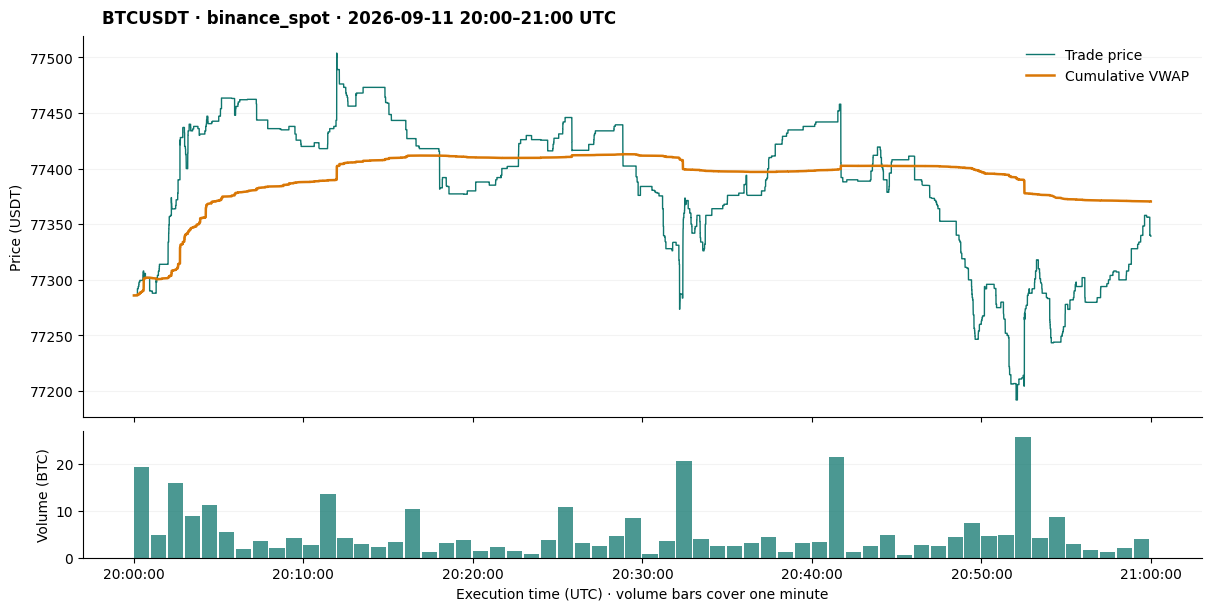

In [10]:
BASE_ASSET = "BTC"
QUOTE_ASSET = "USDT"

notional = trades["price"] * trades["quantity"]
trades["cumulative_vwap"] = notional.cumsum() / trades["quantity"].cumsum()
summary = pd.DataFrame({
    "measure": ["Retained trades", f"Volume ({BASE_ASSET})", f"VWAP ({QUOTE_ASSET})",
                "Capture delay p50 (ms)", "Capture delay p95 (ms)"],
    "value": [len(trades), trades["quantity"].sum(),
              notional.sum() / trades["quantity"].sum(),
              trades["capture_delay_ms"].quantile(0.50),
              trades["capture_delay_ms"].quantile(0.95)],
})
display(summary)

minute_volume = bars.set_index("time")["volume"].resample("1min").sum(min_count=1)

with plt.rc_context({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False}):
    fig, (price_ax, volume_ax) = plt.subplots(
        2, 1, figsize=(12, 6), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}, layout="constrained",
    )
    fig.suptitle(f"{SYMBOL} · {EXCHANGE} · {request.start:%Y-%m-%d %H:%M}–{request.end:%H:%M} UTC", x=0.08, ha="left", fontweight="bold")
    price_ax.plot(trades["execution_time"], trades["price"], color="#0f766e", linewidth=1, label="Trade price")
    price_ax.plot(trades["execution_time"], trades["cumulative_vwap"], color="#d97706", linewidth=1.8, label="Cumulative VWAP")
    price_ax.set_ylabel(f"Price ({QUOTE_ASSET})")
    price_ax.legend(frameon=False, loc="best")
    volume_ax.bar(minute_volume.index, minute_volume, width=54 / 86400, align="edge", color="#0f766e", alpha=0.75)
    volume_ax.set_ylabel(f"Volume ({BASE_ASSET})")
    volume_ax.set_xlabel("Execution time (UTC) · volume bars cover one minute")
    volume_ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S", tz=timezone.utc))
    for axis in (price_ax, volume_ax):
        axis.grid(axis="y", alpha=0.15)
        axis.set_axisbelow(True)
    plt.show()

## Continue with your own research

- Change the market and interval in section 2; rerun from there to create a new
  run using the same verified cache. Keep the asset labels in section 7 accurate.
- Set `OFFLINE = True` to repeat this entire workflow from the cache without
  discovery or downloads. Retain cached files referenced by the manifest for
  full source provenance.
- Native `mark_price`, `ticker`, `open_interest` and `liquidations` data are
  available through `client.download()` and `client.iter_records()`. Preserve
  their own semantics rather than ingesting them as trades.
- Order-book ingestion requires a complete snapshot. Use `book_start` for earlier
  warmup when necessary; an hourly file may contain only deltas. This trade
  notebook does not assume that a snapshot exists for the selected hour.

The [CHD integration guide](../docs/CHD.md) explains all datasets, timestamps,
quality rules, snapshot warmup, cache receipts, CLI equivalents and the REST/SDK
design decision. For example, query this notebook's database from the repository:

```bash
python cli.py query --db data/chd-runs/<your-run>/mdrap.db --latest CHD:binance_spot:BTCUSDT
```